In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Optional: makes plots cleaner
plt.rcParams["figure.figsize"] = (8, 5)

In [7]:
df = pd.read_csv(
    '/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv',
    encoding='latin1'
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:

df.info()
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [17]:
# Which category drives the most sales?
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)


Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [18]:
# Which category drives the most profit?
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

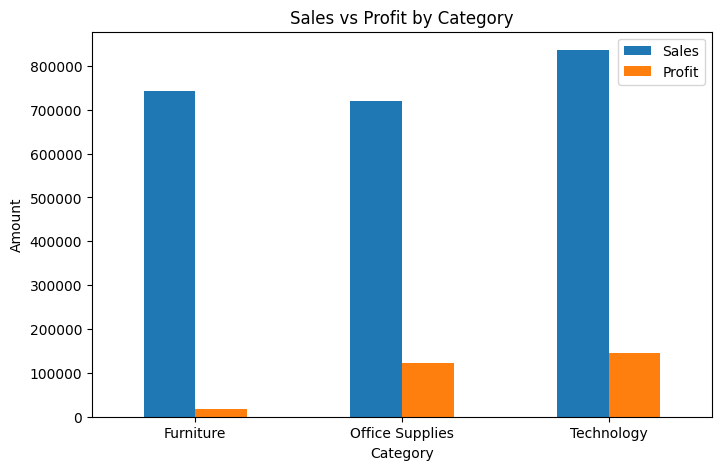

In [57]:
## Sales and profit by catgeory
category_sales_profit = df.groupby("Category")[["Sales", "Profit"]].sum()

category_sales_profit.plot(kind="bar")

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

### Insight

Technology generated the highest sales (\\$836K) and profit (\\$145K).
Furniture generated comparable sales (\$742K) but only \\$18K in profit,
suggesting significantly lower profit margins.

In [19]:
# Which region drives the most sales?
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [20]:
# Which region drives the most profit?
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

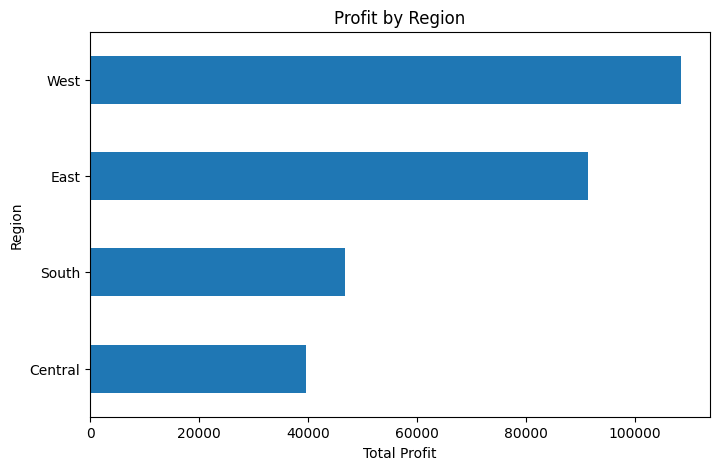

In [58]:
## Profit by region
profit_by_region = df.groupby("Region")["Profit"].sum().sort_values()

profit_by_region.plot(kind="barh")

plt.title("Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Region")
plt.show()

## Insight
The West region dominates in profit and sales 

In [21]:
# Which segment drives the most sales?
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

In [22]:
# Which segment drives the most profit?
df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

In [ ]:
# insights
## The consumer segment leads in sales and profit

## Insight
The consumer segment leads in sales and profit

In [25]:
# Do discounts hurt sales?
df.groupby('Discount')['Sales'].mean().sort_index()

Discount
0.00    226.742074
0.10    578.397351
0.15    529.971567
0.20    209.076940
0.30    454.742974
0.32    536.794770
0.40    565.134874
0.45    498.634000
0.50    892.705152
0.60     48.150000
0.70     97.177708
0.80     56.545853
Name: Sales, dtype: float64

In [26]:
# Do discounts hurt profit?
df.groupby('Discount')['Profit'].mean().sort_index()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

<Axes: xlabel='Discount'>

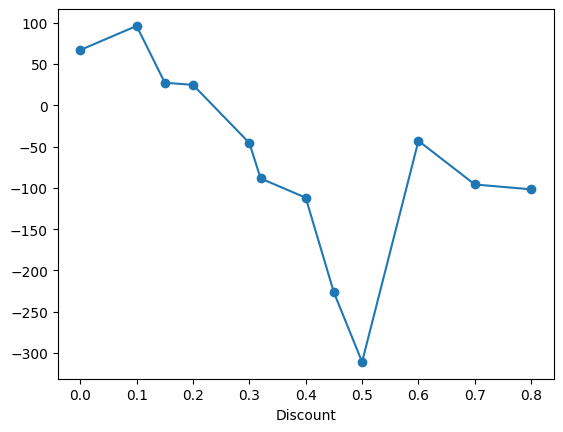

In [42]:
# Discounts VS Profit 
df.groupby('Discount')['Profit'].mean().plot(kind='line', marker='o')

In [28]:
# How many observations are there at each discount level
df.groupby('Discount').size()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
dtype: int64

### Insight: Impact of Discounts on Profitability

Discounting appears to have a significant negative impact on profitability. While orders with discounts of 0% and 10% generated positive average profits, average profit declined sharply as discount levels increased. Orders discounted by 30% or more consistently produced negative average profits, suggesting that aggressive discounting erodes profit margins. Given the large number of observations at these discount levels, the relationship appears to be meaningful rather than driven by a small sample of transactions.

In [29]:
# Which specific product types cause the most loss of profit?
df.groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

### Insight: Profitability Varies Significantly by Product Type

While most product categories generated positive profits, several sub-categories consistently underperformed. Tables generated the largest loss at approximately $17,700, followed by Bookcases and Supplies. In contrast, Copiers, Phones, and Accessories were the most profitable products. These findings suggest that management should investigate pricing, costs, and discounting strategies for underperforming furniture products while continuing to invest in high-performing technology products.

<Axes: ylabel='Sub-Category'>

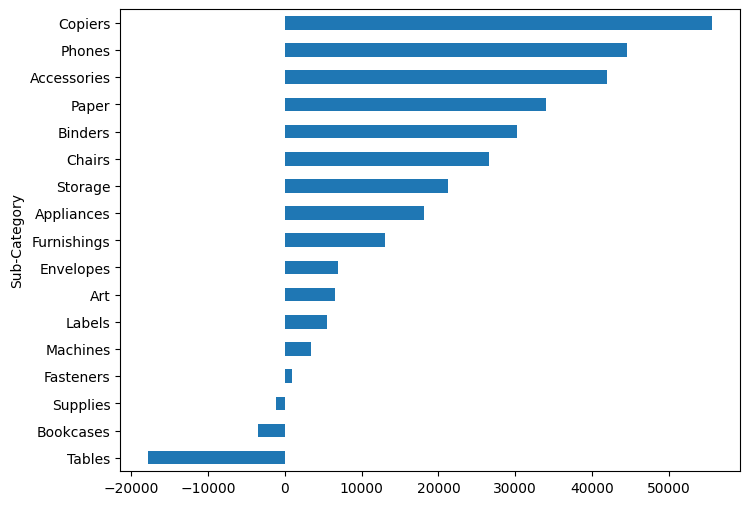

In [40]:
# Sub-Categories by Profit
df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='barh', figsize=(8,6))

In [31]:
# Are tables driving lots of sales along side the loss in profit?
df.groupby('Sub-Category')['Sales'].sum().sort_values()

Sub-Category
Fasteners        3024.2800
Labels          12486.3120
Envelopes       16476.4020
Art             27118.7920
Supplies        46673.5380
Paper           78479.2060
Furnishings     91705.1640
Appliances     107532.1610
Bookcases      114879.9963
Copiers        149528.0300
Accessories    167380.3180
Machines       189238.6310
Binders        203412.7330
Tables         206965.5320
Storage        223843.6080
Chairs         328449.1030
Phones         330007.0540
Name: Sales, dtype: float64

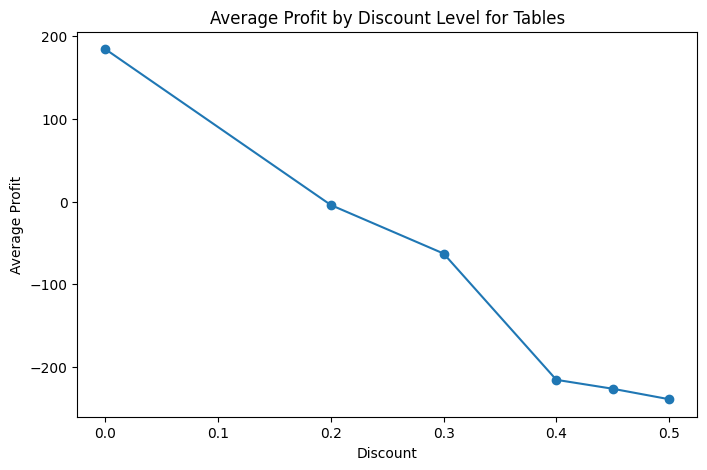

In [55]:
#Profit VS Discounts for Tables
table_discount_profit = (
    df[df["Sub-Category"] == "Tables"]
    .groupby("Discount")["Profit"]
    .mean()
    .sort_index()
)

table_discount_profit.plot(kind="line", marker="o")

plt.title("Average Profit by Discount Level for Tables")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

## Insight
Tables are one of the leading sub-categories in sales, but they are causing the business to lose out on a lot of money. Thus, highlihgting inefficiencies in pricing, costs, or discounting

In [34]:
# How much discount are we giving to table sales?
df[df['Sub-Category'] == 'Tables']['Discount'].describe()

count    319.000000
mean       0.261285
std        0.169622
min        0.000000
25%        0.200000
50%        0.300000
75%        0.400000
max        0.500000
Name: Discount, dtype: float64

In [35]:
# How much profit are we losing from tables?
df[df['Sub-Category'] == 'Tables']['Profit'].describe()

count     319.000000
mean      -55.565771
std       230.565006
min     -1862.312400
25%      -122.829300
50%       -31.372200
75%        33.851700
max       629.010000
Name: Profit, dtype: float64

In [36]:
# How much profit do table sales make at each discount level?
df[df['Sub-Category']=='Tables'].groupby('Discount')['Profit'].mean().sort_index()

Discount
0.00    184.393051
0.20     -4.275465
0.30    -63.006067
0.40   -215.831957
0.45   -226.646464
0.50   -239.316314
Name: Profit, dtype: float64

## Insight
Although tables generated over $206,000 in revenue, they're casuing losses of approximately \\$17,700. It was revealed that an average discount of 26% was applied on all table sales, with 50% of the sales being discounted at least 30%. Table sales without discounts generated an average profit of \\$184 per order, while sales discounted by 30% lost an average of \\$63 per order.cAt discounts of 40% or more, losses exceeded \\$200 per order on average. These findings suggest that aggressive discounting is a primary driver of losses within the Tables sub-category. Management should review table pricing and promotional strategies in order to improve profitability while maintaining sales volume 

In [50]:
# Predictive Analysis
df[df['Sub-Category']=='Tables'][['Discount','Profit']].corr()

,Discount,Profit
Discount,1.00000,-0.67177
Profit,-0.67177,1.00000


## Findings 
A correlation of -0.67 means there is a strong negative relationship between discounts and profits for Tables.

# Conclusion

This analysis examined sales and profitability patterns across products, regions, customer segments, and discount levels.

Key findings include:

- Technology generated the highest sales and profit among all product categories.
- The West region was the strongest-performing geographic market.
- Consumer customers contributed the largest share of revenue and profit.
- Discounts above 30% were consistently associated with negative average profits.
- Tables generated over \\$206,000 in sales but lost approximately \\$17,700 in profit.
- A correlation analysis found a strong negative relationship (-0.67) between discounts and profits for Table sales, suggesting that aggressive discounting is a major driver of losses within this product line.

These findings suggest that management should review discounting strategies, particularly for furniture products, while continuing to invest in high-performing technology products and profitable customer segments.

## Business Recommendations

Based on the analysis, several opportunities exist to improve profitability and optimize business performance.

### 1. Reevaluate Discounting Strategies for Tables

Tables generated over \\$206,000 in sales but approximately \\$17,700 in losses, making them the least profitable product sub-category. Further analysis revealed a strong negative correlation (-0.67) between discounts and profits for Table sales. Management should review promotional pricing and discount policies to reduce excessive discounting while preserving sales volume.

### 2. Increase Focus on High-Profit Technology Products

Technology generated the highest overall sales and profits among all product categories. High-performing sub-categories such as Copiers, Phones, and Accessories consistently contributed strong profits and may represent opportunities for additional marketing investment and inventory expansion.

### 3. Investigate Underperforming Furniture Products

While Furniture generated substantial revenue, its profitability lagged significantly behind other categories. Product lines such as Tables and Bookcases should be evaluated to identify pricing, cost, or operational factors contributing to weak margins.


## Limitations

This analysis identified several relationships between product performance, discounts, and profitability. However, it does not establish causation and does not account for product costs, inventory levels, marketing expenditures, or external market conditions. Future analysis could explore regional performance drivers and build predictive models to estimate profitability before sales occur.